In [1]:
import pandas as pd
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
from concurrent.futures import ThreadPoolExecutor, as_completed
import time, json, pathlib
from tqdm import tqdm   # <-- progress bar

# --- Load & pick your subset (example: Cepheids) ---
url = "https://ned.ipac.caltech.edu/Archive/Distances/NED30.5.1-D-17.1.2-20200415.csv"
ned_df = pd.read_csv(url, skipinitialspace=True)
ned_df.columns = [
    "Exclusion Code","D","G","Galaxy ID","m-M","err","D (Mpc)","Method",
    "REFCODE","","","Hubble const.","Adopted LMC modulus","Date (Yr. - 1980)","Notes"
]
df = ned_df[ned_df["Method"].str.contains("cepheid", case=False, na=False)].copy()

names = (df["Galaxy ID"].astype(str).str.strip()
         .replace({"": np.nan}).dropna().unique().tolist())

# --- Cache ---
cache_path = pathlib.Path("name_resolve_cache.json")
cache = {}
if cache_path.exists():
    try:
        cache = json.loads(cache_path.read_text())
    except Exception:
        pass

def resolve_one(name, retries=2, pause=0.2):
    if name in cache:
        return name, cache[name]["ra"], cache[name]["dec"]
    for i in range(retries + 1):
        try:
            c = SkyCoord.from_name(name)
            ra, dec = float(c.ra.degree), float(c.dec.degree)
            cache[name] = {"ra": ra, "dec": dec}
            return name, ra, dec
        except Exception:
            if i < retries:
                time.sleep(pause * (i + 1))
            else:
                return name, None, None

# --- Parallel with tqdm progress ---
results = []
with ThreadPoolExecutor(max_workers=8) as ex:
    futs = {ex.submit(resolve_one, nm): nm for nm in names}
    for fut in tqdm(as_completed(futs), total=len(futs), desc="Resolving"):
        results.append(fut.result())

# Save cache
try:
    cache_path.write_text(json.dumps(cache))
except Exception:
    pass

coords = pd.DataFrame(results, columns=["Galaxy ID", "RA", "Dec"])

# Merge back
df_out = df.merge(coords, on="Galaxy ID", how="left")
cols = ["Galaxy ID", "RA", "Dec", "m-M", "err", "D (Mpc)", "Method", "REFCODE"]
df_out = df_out[[c for c in cols if c in df_out.columns]]

df_out.to_csv("ned_cepheids_with_coords.csv", index=False)
print(f"Resolved {df_out['RA'].notna().sum()} / {len(df_out)} rows")


/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_13558/4080234927.py:11: DtypeWarning: Columns (1,2,4,5,6,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  ned_df = pd.read_csv(url, skipinitialspace=True)
Resolving: 100%|██████████| 9224/9224 [46:53<00:00,  3.28it/s]  

Resolved 3520 / 20351 rows


In [3]:
from astropy.io import fits
from astropy.table import Table

# Read data/larfs_r90.fits
with fits.open('data/larfs_r90.fits') as hdul:
    larfs_data = Table(hdul[1].data)
    larfs_df = larfs_data.to_pandas()

larfs_df.head()

,Name,_2MRS,Seyfert,Sy1,Sy2,LINER,HII,Starburst,RAJ2000,DEJ2000,...,W2-W3,logLW1,logLW3,l_logLnuc,logLnuc,e_logLnuc,logLint,S18,SimbadName,recno
0,UGC 00006,true,true,true,true,false,true,false,0.79009,21.96016,...,3.506,43.599998,43.799999,false,43.580002,0.57,NaN,true,UGC 00006,1
1,MCG -01-01-069,true,true,true,false,false,true,false,4.36917,-3.23050,...,3.015,42.799999,43.200001,false,42.810001,0.57,NaN,true,MCG -01-01-069,2
2,2MASX J00193596-0440105,true,true,false,true,true,false,false,4.89999,-4.66957,...,3.160,43.400002,43.599998,false,43.209999,0.57,NaN,true,2MASX J00193596-0440105,3
3,2MASX J00253292+6821442,false,true,false,true,false,false,false,6.38696,68.36228,...,3.085,42.900002,42.900002,false,42.619999,0.22,43.200001,true,2MASX J00253292+6821442,4
4,ESO 350-IG 038,false,false,false,false,false,true,false,9.21958,-33.55472,...,4.456,43.200001,44.000000,false,43.389999,0.23,NaN,false,ESO 350-IG 038,5


In [8]:
import re
from astropy.coordinates import SkyCoord, search_around_sky

larfs_df = larfs_df.dropna(subset=['RAJ2000', 'DEJ2000'])
df_out = df_out.dropna(subset=['RA', 'Dec'])

# Build SkyCoord objects for larfs_df and ned_df
coords_larfs = SkyCoord(ra=larfs_df['RAJ2000'], dec=larfs_df['DEJ2000'], unit='deg')

coords_ned = SkyCoord(ra=df_out['RA'], dec=df_out['Dec'], unit='deg')

# Match within 1 arcsec
idx_larfs, idx_ned, sep2d, _ = search_around_sky(coords_larfs, coords_ned, 1*u.arcsec)

matched_larfs = larfs_df.iloc[idx_larfs].reset_index(drop=True)
matched_ned = df_out.iloc[idx_ned].reset_index(drop=True)
matched_larfs['sep_arcsec'] = sep2d.arcsec

matched_larfs_ned = pd.concat([matched_larfs, matched_ned], axis=1)
matched_larfs_ned.head()

,Name,_2MRS,Seyfert,Sy1,Sy2,LINER,HII,Starburst,RAJ2000,DEJ2000,...,recno,sep_arcsec,Galaxy ID,RA,Dec,m-M,err,D (Mpc),Method,REFCODE
0,NGC 4395,true,true,true,true,true,false,true,186.45359,33.54693,...,99,0.248753,NGC 4395,186.453597,33.546861,28.15,0.18,4.3,Cepheids,2004AJ....127.2322T



No surprise!

Check NGC 4258 (X not an optical AGN),

NGC 4395,

NGC 4151

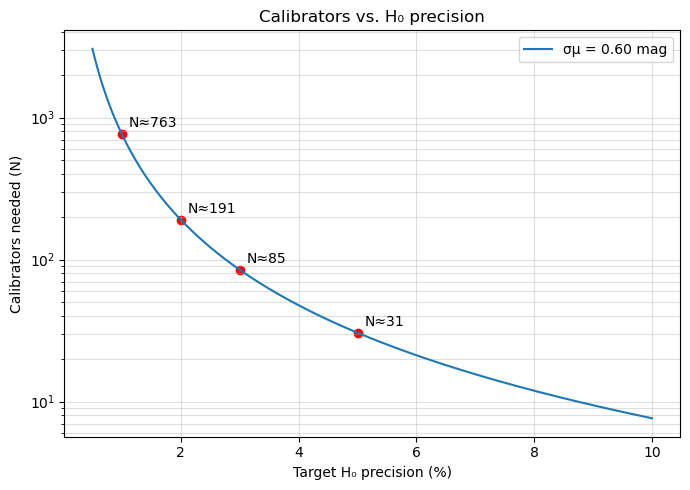

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- User input: per-object scatter in magnitudes ---
sigma_mu = 0.60   # change this to your scatter (mag)

# Formula: fractional H0 precision f vs. calibrators N
# N = (0.4605 * sigma_mu / f)^2
def n_calibrators_needed(sigma_mu, f_frac):
    return (0.4605 * sigma_mu / f_frac) ** 2

# Range of target precisions (fractional, e.g., 0.01 = 1%)
f_range = np.linspace(0.005, 0.10, 400)  # 0.5% – 10%
N_vals = n_calibrators_needed(sigma_mu, f_range)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(100 * f_range, N_vals, label=f"σμ = {sigma_mu:.2f} mag")
plt.yscale("log")
plt.xlabel("Target H₀ precision (%)")
plt.ylabel("Calibrators needed (N)")
plt.title("Calibrators vs. H₀ precision")
plt.grid(True, which="both", alpha=0.4)

# Annotate common target precisions
targets = np.array([0.01, 0.02, 0.03, 0.05])  # 1%, 2%, 3%, 5%
for f in targets:
    N = n_calibrators_needed(sigma_mu, f)
    plt.scatter(100*f, N, color="red")
    plt.annotate(f"N≈{int(round(N))}", (100*f, N), textcoords="offset points", xytext=(5,5))

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Read the LARS survey, match that to ZTF